# 바이크 수요 예측하기!

하지만 하루 중 어떤 시간대, 어떤 계절, 어떤 날씨에 사람들이 자전거를 얼마나 빌려 탈지 **정확히 예측하는 것**은 쉽지 않은 문제입니다.  

이 문제는 2011~2012년 워싱턴 D.C.의 실제 자전거 대여 데이터를 바탕으로,  
**날짜·시간·기상 정보** 같은 다양한 변수를 활용해 **자전거 대여 수요(`count`)** 를 예측하는 머신러닝 회귀 문제입니다.  

👉 이 문제를 통해 우리는  
- **EDA**로 계절·날씨·시간대와 수요의 관계를 탐색하고,  
- **전처리와 피처 엔지니어링**으로 데이터 품질을 개선하며,  
- **여러 고전적 ML 모델**을 적용해 성능을 비교하는 과정을 경험할 수 있습니다.  


### 오늘의 목표

1. MSE 손실함수값 3000 이하를 달성
2. RMSE 값 150 이하를 달성
3. 데이터 시각화 및 예측결과 시각화를 모두 진행하였다.

# 01_데이터 불러오기 및 EDA

In [ ]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train = pd.read_csv('train.csv')

In [ ]:
# 결측치 보이지 않음
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
train.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [ ]:
train.head(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


In [ ]:
# 파악이 안되는 column은 value_counts() 함수로 데이터 구조 파악')
# season, holiday, workingday, weather column 은 범주형 데이터 변환한 것으로 파악됨
# casual, registered,cloumn 은 어떤 정보를 담고 있는지 잘 모르겠음 (count 는 대여 수요로 보임)

print('season:', train['season'].value_counts())
print('-'*30)
print('holiday:', train['holiday'].value_counts())
print('-'*30)
print('workingday:', train['workingday'].value_counts())
print('-'*30)
print('weather:', train['weather'].value_counts())
print('-'*30)
print('casual:', train['casual'].value_counts())
print('-'*30)
print('registered:', train['registered'].value_counts())
print('-'*30)
print('count:', train['count'].value_counts())

season: season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64
------------------------------
holiday: holiday
0    10575
1      311
Name: count, dtype: int64
------------------------------
workingday: workingday
1    7412
0    3474
Name: count, dtype: int64
------------------------------
weather: weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64
------------------------------
casual: casual
0      986
1      667
2      487
3      438
4      354
      ... 
294      1
280      1
216      1
292      1
304      1
Name: count, Length: 309, dtype: int64
------------------------------
registered: registered
3      195
4      190
5      177
6      155
2      150
      ... 
709      1
699      1
720      1
788      1
803      1
Name: count, Length: 731, dtype: int64
------------------------------
count: count
5      169
4      149
3      144
6      135
2      132
      ... 
842      1
683      1
863      1
725      1
637      1
Name: count, Length: 822

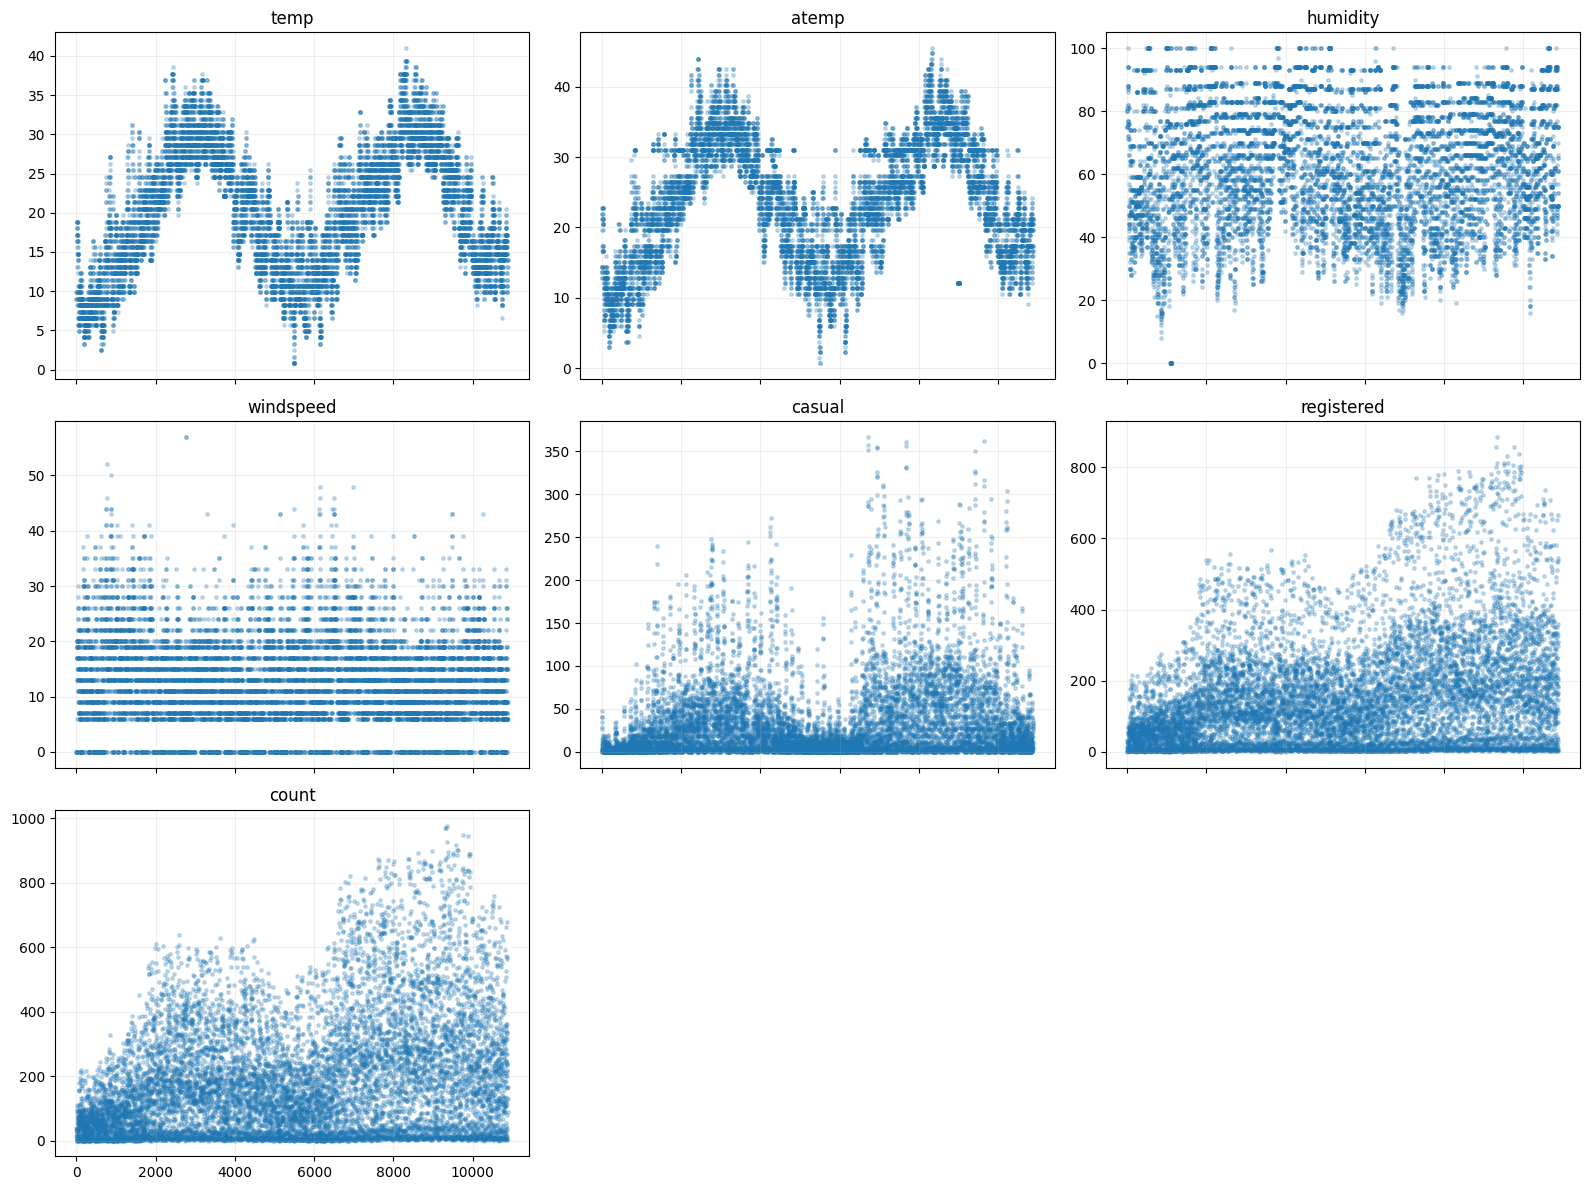

In [ ]:
# 이상치 파악을 위한 시각화
# 이상치로 의심되는 데이터가 일부 보이지만 판단하기 어려움
# 다만, windspeed column 은 측정치가 0으로 깔리는 값들이 많고 일부 값들은 전부 비어있음, 측정오류 가능성 있음

df = train.copy()

cols = ["temp","atemp","humidity","windspeed","casual","registered","count"]

x = df.index  # 인덱스 vs 값

ncols = 3
nrows = int(np.ceil(len(cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cols):
    ax = axes[i]
    ax.scatter(x, df[col], s=6, alpha=0.25)
    ax.set_title(col)
    ax.grid(True, alpha=0.2)

# 남는 축 제거
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

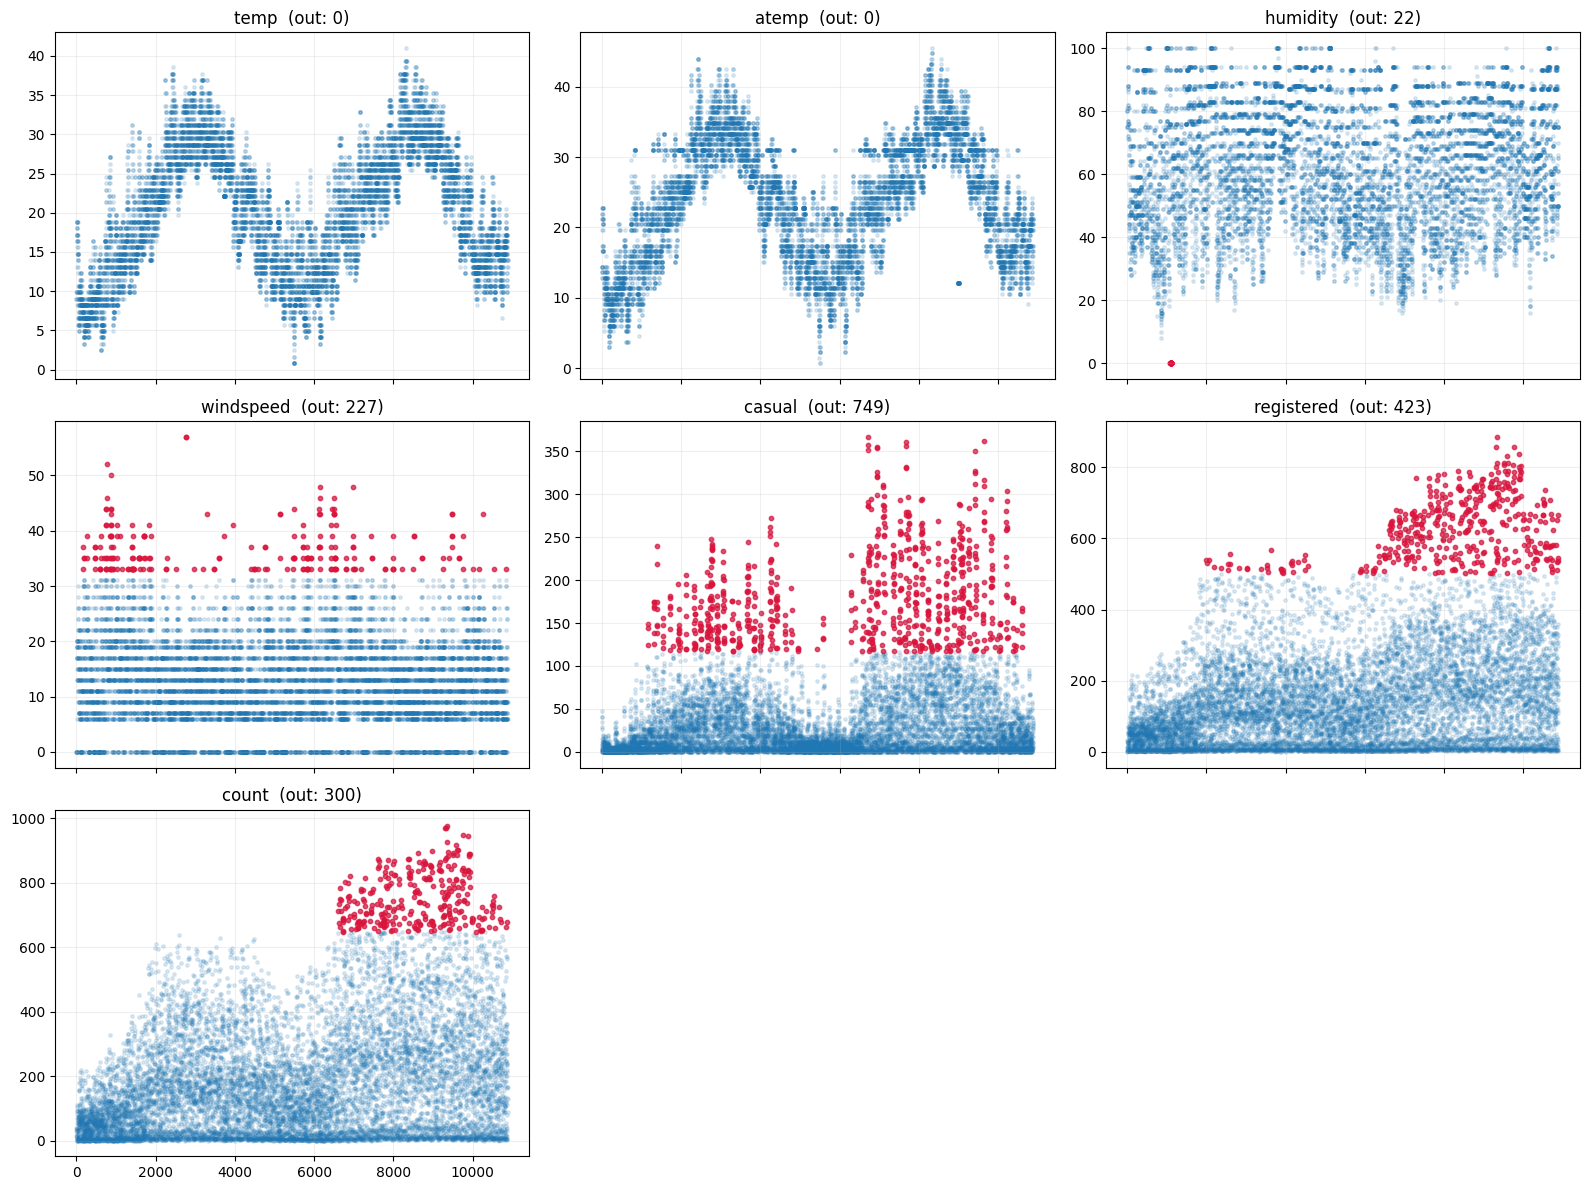

In [ ]:
# IQR 밖 점만 빨간색으로표시
# IQR 기준이 유의미한 필터링을 하고 있는것으로 보기 어려움

df = train.copy()
cols = ["temp","atemp","humidity","windspeed","casual","registered","count"]
x = df.index

ncols = 3
nrows = int(np.ceil(len(cols)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cols):
    s = df[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = (s < lo) | (s > hi)

    ax = axes[i]
    ax.scatter(x, s, s=6, alpha=0.15, color="tab:blue")
    ax.scatter(x[out], s[out], s=10, alpha=0.7, color="crimson")
    ax.set_title(f"{col}  (out: {out.sum()})")
    ax.grid(True, alpha=0.2)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

#02_데이터 정제

In [ ]:
# datetime column 을 datetime type 으로 변환
train_df['datetime'] = pd.to_datetime(train_df['datetime'])

# 연/월/일/시 를 새로운 컬럼으로 생성
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour

In [ ]:
# 연/월/일/시 컬럼의 구성 확인
print('year:', train['year'].value_counts())
print('-'*30)
print('month:', train['month'].value_counts())
print('-'*30)
print('day:', train['day'].value_counts())
print('-'*30)
print('hour:', train['hour'].value_counts())

year: year
2012    5464
2011    5422
Name: count, dtype: int64
------------------------------
month: month
8     912
7     912
6     912
5     912
12    912
10    911
11    911
4     909
9     909
2     901
3     901
1     884
Name: count, dtype: int64
------------------------------
day: day
1     575
9     575
5     575
17    575
16    574
19    574
7     574
8     574
15    574
13    574
4     574
14    574
2     573
3     573
12    573
6     572
10    572
11    568
18    563
Name: count, dtype: int64
------------------------------
hour: hour
16    456
17    456
18    456
19    456
12    456
13    456
14    456
15    456
20    456
21    456
22    456
23    456
8     455
6     455
7     455
0     455
10    455
9     455
11    455
1     454
5     452
2     448
4     442
3     433
Name: count, dtype: int64


# 03_모델 학습을 위한 사전준비

## 03-1_다중공선성 확인을 위한 변수간 상관관계 분석

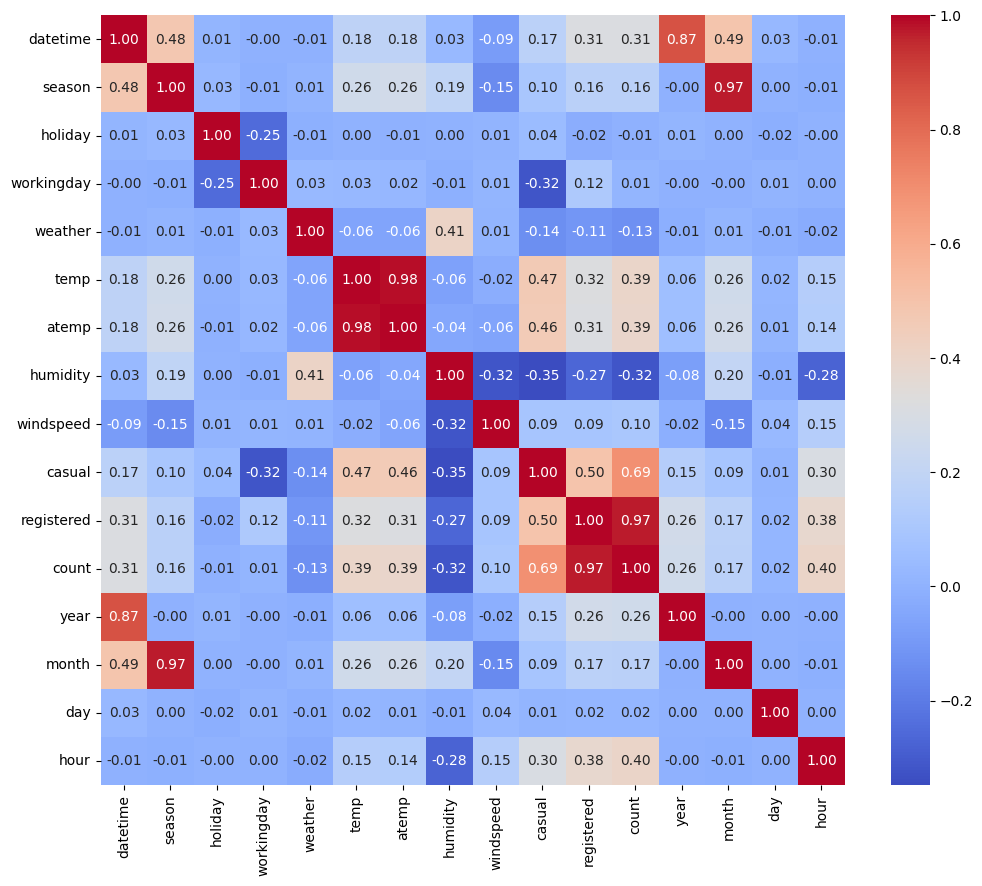

In [ ]:
# 상관관계 히트맵 작성
plt.figure(figsize=(12, 10))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
# VIF(Variance Inflation Factor) 계산
# 계산결과 temp/atemp 값이 매우 큼

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = train.copy()
numeric_cols = X_vif.select_dtypes(include=['int64', 'float64']).columns

vif_data = pd.DataFrame()
vif_data["feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(X_vif[numeric_cols].values, i) for i in range(X_vif[numeric_cols].shape[1])]

print("VIF values:")
display(vif_data)

VIF values:


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,season,6.820092
1,holiday,1.094765
2,workingday,4.072190
3,weather,7.355967
4,temp,263.959086
5,atemp,292.306415
6,humidity,12.913588
7,windspeed,3.076292
8,casual,inf
9,registered,inf


# 04_회귀모델 돌리기

## 04-1_전처리없이 진행

In [ ]:
from sklearn.model_selection import train_test_split

# 다중공선성을 확인했지만, 만약 변수 전처리를 하지 않으면 어떻게 되는지 봅시다.
# datetime 열은 분리를 했으니 그래도 제거해야겠죠?
# 또, 'casual', 'registered' 열은 타겟변수와 관계가 커 미리 제거합니다.
# 제거하지 않으면 무슨 일이 일어나는지 체크해보셔도 좋아요~
X = train.drop(['count', 'casual', 'registered', 'datetime'], axis=1)
y = train['count']


# 훈련 데이터와 테스트 데이터 분리
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 선형회귀 모델
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# MSE 및 RMSE 계산
from sklearn.metrics import mean_squared_error as mse
mse_error = mse(y_pred,y_test)
rmse_error = mse_error ** 0.5
print('mse error = ', mse_error)
print('rmse error = ', rmse_error)

mse error =  19945.370053754057
rmse error =  141.22807813517133


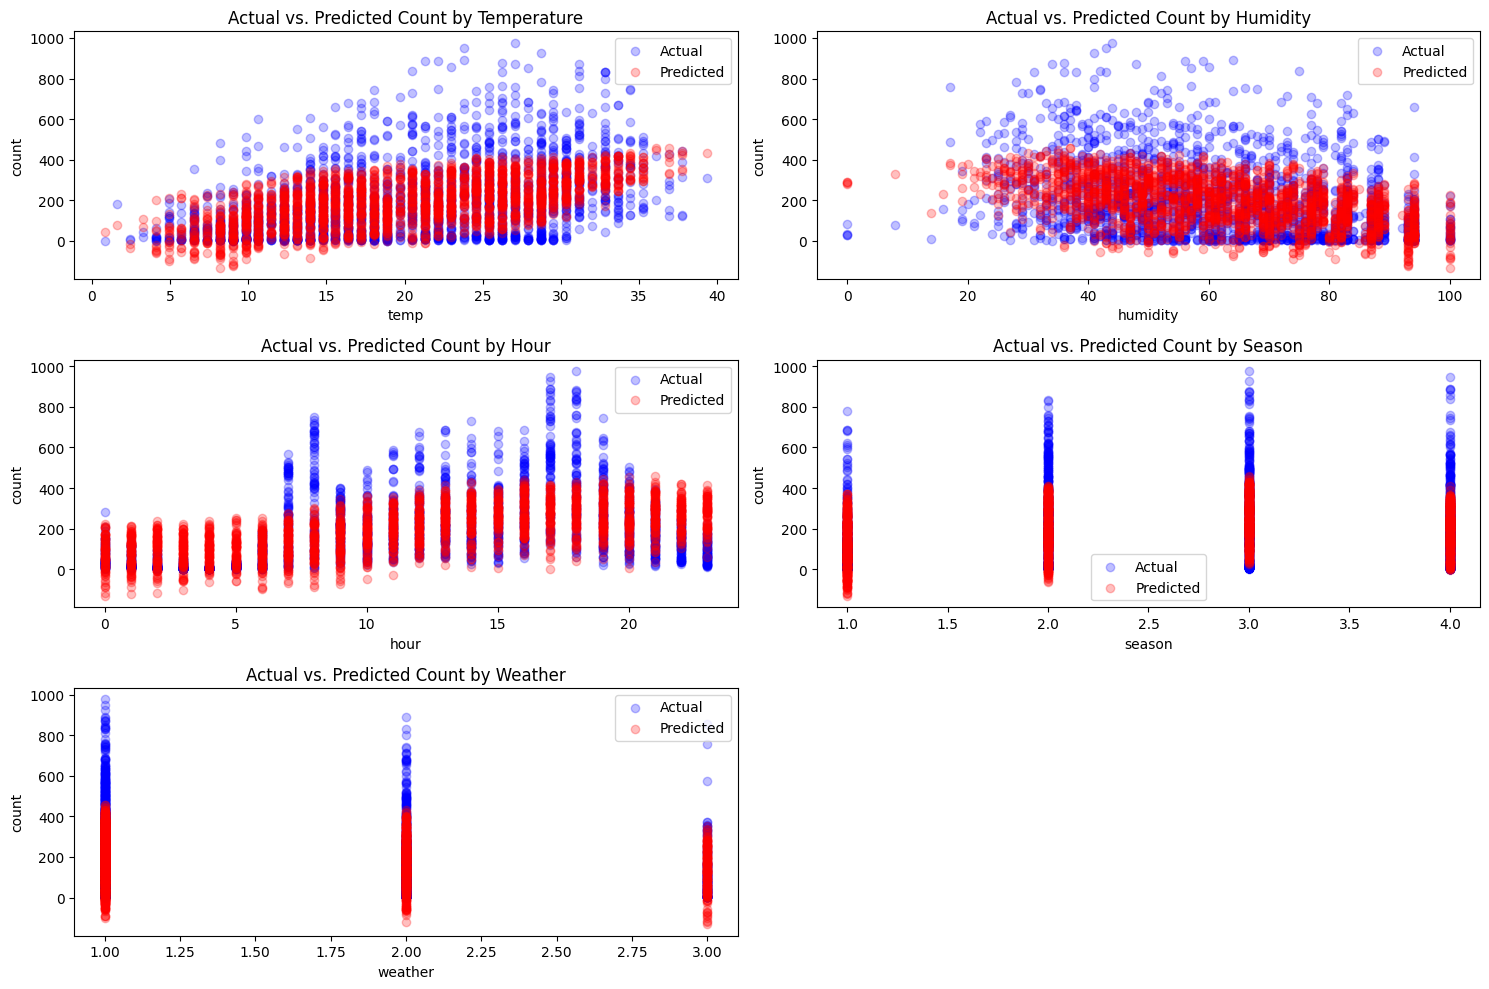

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(321)
plt.scatter(X_test['temp'], y_test, alpha=0.25, c ='b', label='Actual')
plt.scatter(X_test['temp'], y_pred, alpha=0.25, c='r', label='Predicted')
plt.xlabel('temp')
plt.ylabel('count')
plt.title('Actual vs. Predicted Count by Temperature')
plt.legend()

plt.subplot(322)
plt.scatter(X_test['humidity'], y_test, alpha=0.25, c='b', label='Actual')
plt.scatter(X_test['humidity'], y_pred, alpha=0.25, c='r', label='Predicted')
plt.xlabel('humidity')
plt.ylabel('count')
plt.title('Actual vs. Predicted Count by Humidity')
plt.legend()

plt.subplot(323)
plt.scatter(X_test['hour'], y_test, alpha=0.25, c='b', label='Actual')
plt.scatter(X_test['hour'], y_pred, alpha=0.25, c='r', label='Predicted')
plt.xlabel('hour')
plt.ylabel('count')
plt.title('Actual vs. Predicted Count by Hour')
plt.legend()

plt.subplot(324)
plt.scatter(X_test['season'], y_test, alpha=0.25, c='b', label='Actual')
plt.scatter(X_test['season'], y_pred, alpha=0.25, c='r', label='Predicted')
plt.xlabel('season')
plt.ylabel('count')
plt.title('Actual vs. Predicted Count by Season')
plt.legend()

plt.subplot(325)
plt.scatter(X_test['weather'], y_test, alpha=0.25, c='b', label='Actual')
plt.scatter(X_test['weather'], y_pred, alpha=0.25, c='r', label='Predicted')
plt.xlabel('weather')
plt.ylabel('count')
plt.title('Actual vs. Predicted Count by Weather')
plt.legend()


plt.tight_layout()
plt.show()

## 04-2_변수제거 피쳐엔지니어링

In [ ]:
from sklearn.model_selection import train_test_split

# 다중공선성을 확인했으니, 적절한 변수 제거를 해봅시다.
X = train.drop(['count', 'casual','registered', 'datetime', 'atemp', 'humidity'], axis=1)
y = train['count']


# 훈련 데이터와 테스트 데이터 분리
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 선형회귀 모델
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# MSE 및 RMSE 계산
from sklearn.metrics import mean_squared_error as mse
mse_error = mse(y_pred,y_test)
rmse_error = mse_error ** 0.5
print('mse error = ', mse_error)
print('rmse error = ', rmse_error)

mse error =  20908.756058943858
rmse error =  144.59860323994786


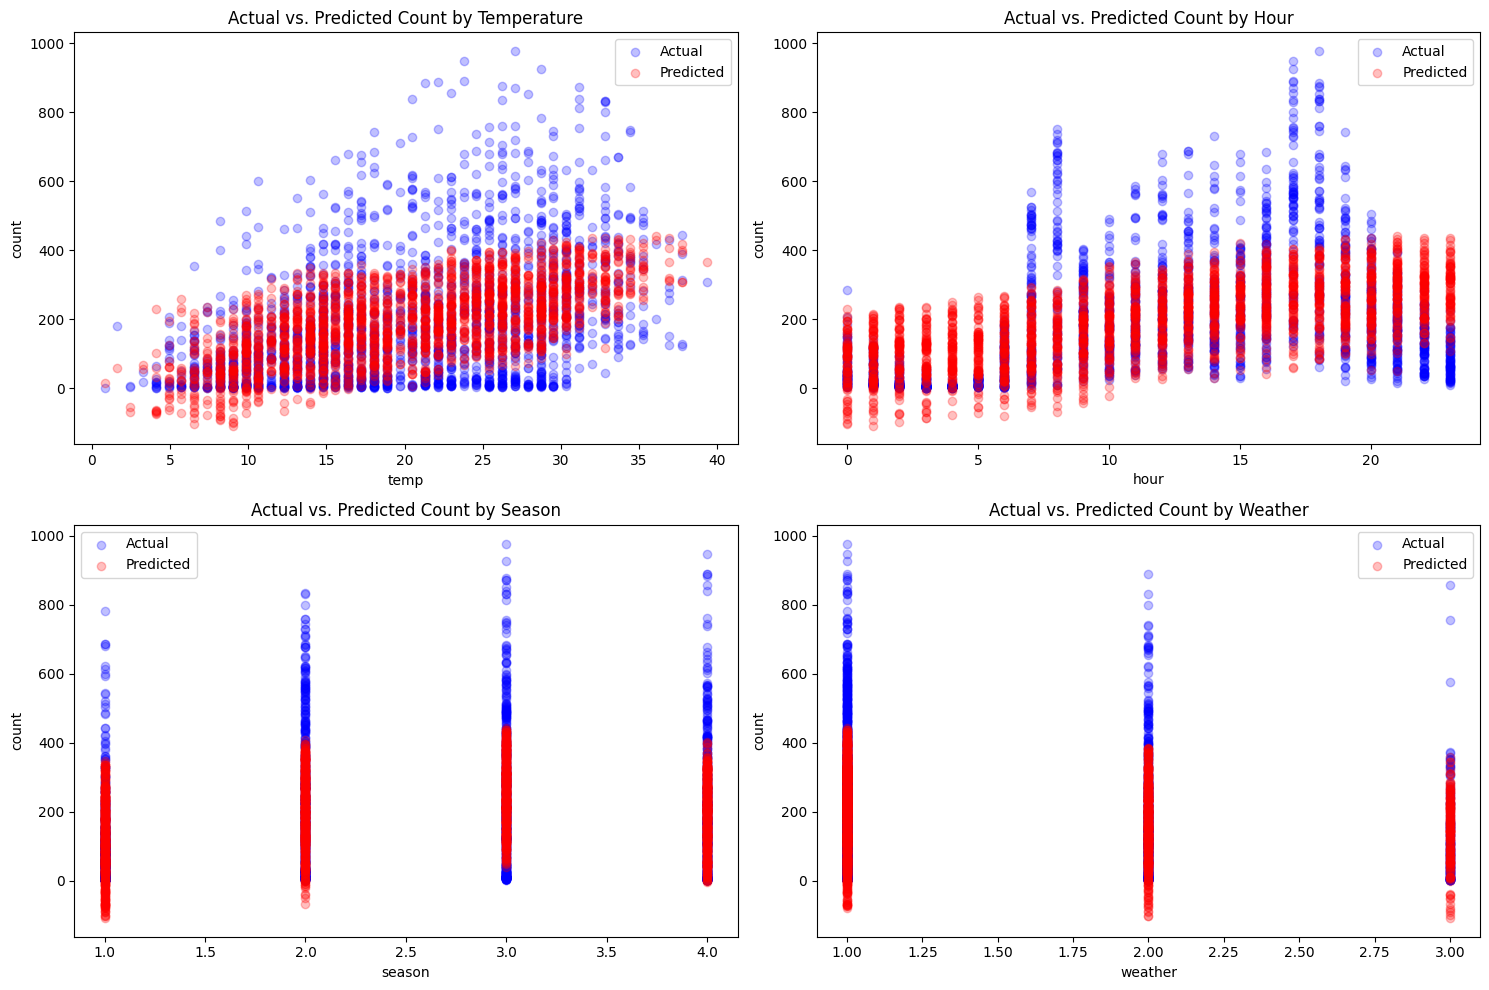

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(221)
plt.scatter(X_test['temp'], y_test, alpha=0.25, c ='b', label='Actual')
plt.scatter(X_test['temp'], y_pred, alpha=0.25, c='r', label='Predicted')
plt.xlabel('temp')
plt.ylabel('count')
plt.title('Actual vs. Predicted Count by Temperature')
plt.legend()

plt.subplot(222)
plt.scatter(X_test['hour'], y_test, alpha=0.25, c='b', label='Actual')
plt.scatter(X_test['hour'], y_pred, alpha=0.25, c='r', label='Predicted')
plt.xlabel('hour')
plt.ylabel('count')
plt.title('Actual vs. Predicted Count by Hour')
plt.legend()

plt.subplot(223)
plt.scatter(X_test['season'], y_test, alpha=0.25, c='b', label='Actual')
plt.scatter(X_test['season'], y_pred, alpha=0.25, c='r', label='Predicted')
plt.xlabel('season')
plt.ylabel('count')
plt.title('Actual vs. Predicted Count by Season')
plt.legend()

plt.subplot(224)
plt.scatter(X_test['weather'], y_test, alpha=0.25, c='b', label='Actual')
plt.scatter(X_test['weather'], y_pred, alpha=0.25, c='r', label='Predicted')
plt.xlabel('weather')
plt.ylabel('count')
plt.title('Actual vs. Predicted Count by Weather')
plt.legend()


plt.tight_layout()
plt.show()

## 04-3_차원축소(PCA)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 아까 전처럼, 불필요한 열과 타겟변수와 역할이 겹치는 열들은 사전에 제거해줍니다
# 하지만 atemp와 humidity처럼 다중공선성이 강하게 나타나는 열들은 이번에 PCA를 통해서 처리해보도록 하죠!
X_pca = train.drop(['count', 'datetime', 'casual', 'registered'], axis=1)
y_pca = train['count']

# PCA를 하기 위해 정규분포로의 표준화를 시도합니다. 분산의 단위를 같게 해줘야죠!
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

pca = PCA()
X_pca_transformed = pca.fit_transform(X_pca_scaled)

# 주성분이 몇개나 될 지 판단해볼까요?
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio by each component:")
print(explained_variance_ratio)

cumulative_explained_variance_ratio = explained_variance_ratio.cumsum()
print("\nCumulative explained variance ratio:")
print(cumulative_explained_variance_ratio)

Explained variance ratio by each component:
[0.21269475 0.15590114 0.10673303 0.10083549 0.08877638 0.08339073
 0.08156057 0.06839645 0.06209976 0.03610207 0.00232986 0.00117978]

Cumulative explained variance ratio:
[0.21269475 0.36859589 0.47532892 0.57616441 0.66494078 0.74833151
 0.82989208 0.89828853 0.96038829 0.99649036 0.99882022 1.        ]


In [ ]:
# 주성분이 몇개라고 생각하시나요?
# 저는 0.89 에서 끊어 8개의 주성분으로 시도해보겠습니다.
pca = PCA(n_components = 8)
X_pca_final = pca.fit_transform(X_pca_scaled)
X_pca_final = pd.DataFrame(X_pca_final)
X_pca_final.columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8']

In [ ]:
y = train['count']


# 훈련 데이터와 테스트 데이터 분리
X_train,X_test,y_train,y_test = train_test_split(X_pca_final,y,test_size=0.2,random_state=42)

# 선형회귀 모델
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# MSE 및 RMSE 계산
from sklearn.metrics import mean_squared_error as mse
mse_error = mse(y_pred,y_test)
rmse_error = mse_error ** 0.5
print('mse error = ', mse_error)
print('rmse error = ', rmse_error)

mse error =  19993.412985339528
rmse error =  141.3980657057922


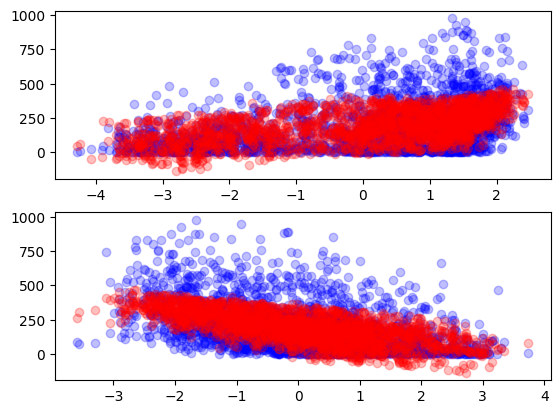

In [ ]:
X_pca_final.columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8']

plt.subplot(211)
plt.scatter(X_test['PC1'], y_test, alpha=0.25, c ='b', label='Actual')
plt.scatter(X_test['PC1'], y_pred, alpha=0.25, c='r', label='Predicted')

plt.subplot(212)
plt.scatter(X_test['PC2'], y_test, alpha=0.25, c ='b', label='Actual')
plt.scatter(X_test['PC2'], y_pred, alpha=0.25, c='r', label='Predicted')

## 04-4_전처리(이상치 확인 및 처리)

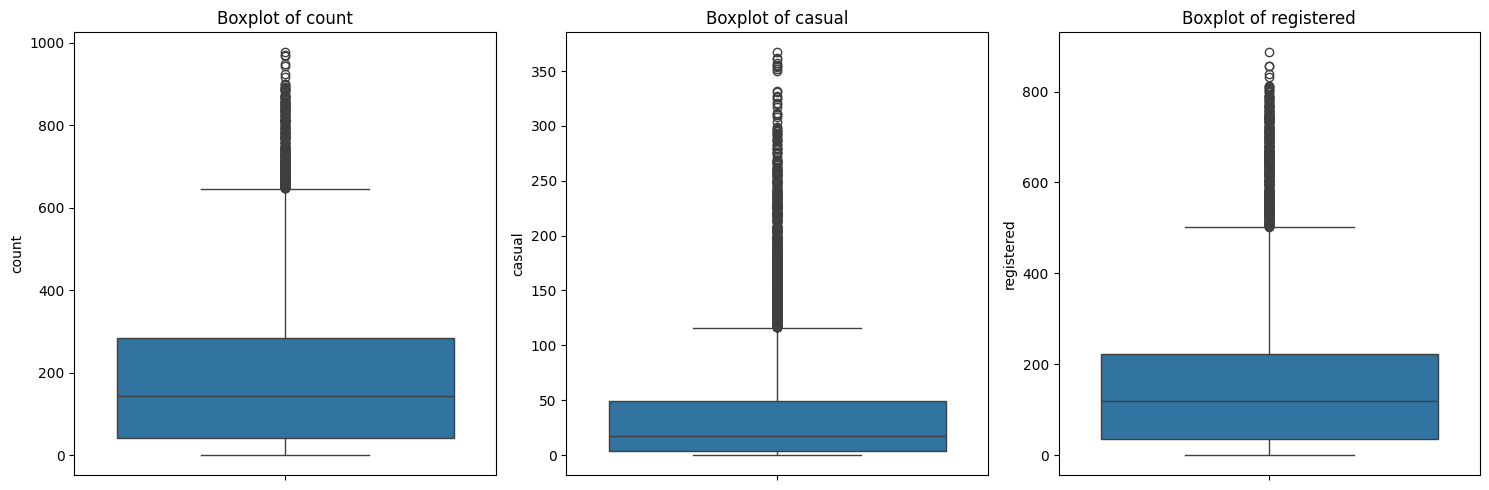

Original data shape: (10886, 16)
Cleaned data shape (after removing outliers in count): (10586, 16)


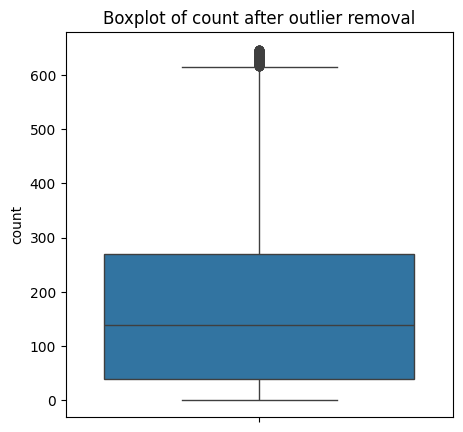

In [ ]:
# 이상치 확인을 위한 Boxplot 그리기
# count, casual, registered 열의 이상치를 확인합니다.
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=train['count'])
plt.title('Boxplot of count')

plt.subplot(1, 3, 2)
sns.boxplot(y=train['casual'])
plt.title('Boxplot of casual')

plt.subplot(1, 3, 3)
sns.boxplot(y=train['registered'])
plt.title('Boxplot of registered')

plt.tight_layout()
plt.show()

# 이상치 처리는 다양한 방법이 있습니다.
# 여기서는 count 열의 이상치를 제거하는 예시를 보여줍니다.
# IQR (Interquartile Range) 방법을 사용하여 이상치를 식별하고 제거할 수 있습니다.

Q1 = train['count'].quantile(0.25)
Q3 = train['count'].quantile(0.75)
IQR = Q3 - Q1

# 이상치 기준 설정 (예: 1.5 * IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거
train_cleaned = train[(train['count'] >= lower_bound) & (train['count'] <= upper_bound)].copy()

print(f"Original data shape: {train.shape}")
print(f"Cleaned data shape (after removing outliers in count): {train_cleaned.shape}")

# 이상치 처리 후 Boxplot 다시 그려서 확인
plt.figure(figsize=(5, 5))
sns.boxplot(y=train_cleaned['count'])
plt.title('Boxplot of count after outlier removal')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 다중공선성을 확인했으니, 적절한 변수 제거를 해봅시다.
X = train_cleaned.drop(['count', 'casual','registered', 'datetime', 'atemp', 'humidity'], axis=1)
y = train_cleaned['count']


# 훈련 데이터와 테스트 데이터 분리
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 선형회귀 모델
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# MSE 및 RMSE 계산
from sklearn.metrics import mean_squared_error as mse
mse_error = mse(y_pred,y_test)
rmse_error = mse_error ** 0.5
print('mse error = ', mse_error)
print('rmse error = ', rmse_error)

mse error =  14683.76680582883
rmse error =  121.17659347344613


# 05_다른 회귀모델 시도하기

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error as mse, mean_squared_log_error as msle
import numpy as np

# Prepare data using the cleaned dataframe and dropping specified columns
X = train_cleaned.drop(['count', 'casual','registered', 'datetime', 'atemp', 'humidity'], axis=1)
y = train_cleaned['count']

# 훈련 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Trains a regression model, makes predictions, and evaluates performance using MSE, RMSE, and RMSLE.

    Args:
        model: The regression model to evaluate.
        X_train: Training features.
        X_test: Testing features.
        y_train: Training target.
        y_test: Testing target.

    Returns:
        A tuple containing the MSE, RMSE, and RMSLE of the model.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Ensure predictions are non-negative for RMSLE
    y_pred[y_pred < 0] = 0

    mse_error = mse(y_test, y_pred)
    rmse_error = mse_error ** 0.5

    # Calculate RMSLE, adding 1 to actual and predicted values
    msle_error = msle(y_test + 1, y_pred + 1)
    rmsle_error = msle_error ** 0.5

    return mse_error, rmse_error, rmsle_error

# Define a list of models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

results = {}

# Evaluate each model
for name, model in models.items():
    mse_error, rmse_error, rmsle_error = evaluate_model(model, X_train, X_test, y_train, y_test)
    results[name] = {"MSE": mse_error, "RMSE": rmse_error, "RMSLE": rmsle_error}
    print(f"{name}: MSE = {mse_error:.2f}, RMSE = {rmse_error:.2f}, RMSLE = {rmsle_error:.4f}")

# Optional: Display results in a DataFrame for easier comparison
results = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
display(results)

Linear Regression: MSE = 14607.36, RMSE = 120.86, RMSLE = 1.1762
Ridge: MSE = 14607.24, RMSE = 120.86, RMSLE = 1.1762
Lasso: MSE = 14587.66, RMSE = 120.78, RMSLE = 1.1710
Decision Tree Regressor: MSE = 3344.37, RMSE = 57.83, RMSLE = 0.4196
Random Forest Regressor: MSE = 1730.82, RMSE = 41.60, RMSLE = 0.3247
Gradient Boosting Regressor: MSE = 4067.09, RMSE = 63.77, RMSLE = 0.6550

Model Performance Comparison:


,MSE,RMSE,RMSLE
Linear Regression,14607.357852,120.860903,1.176186
Ridge,14607.236626,120.860401,1.176151
Lasso,14587.664362,120.779404,1.171048
Decision Tree Regressor,3344.373938,57.830562,0.419618
Random Forest Regressor,1730.822898,41.603160,0.324697
Gradient Boosting Regressor,4067.093747,63.773770,0.654954


 - 선형계열(Linear/Ridge/Lasso)은 RMSE 와 MAPE가 거의 비슷, 규제가 있든 없든 성이 크게 안 바뀜(서로 거의 차이가 없음)
 - 반면 트리계열은 확실히 성능이 좋음, Random Forest Regressor가 세 지표 모두 1등


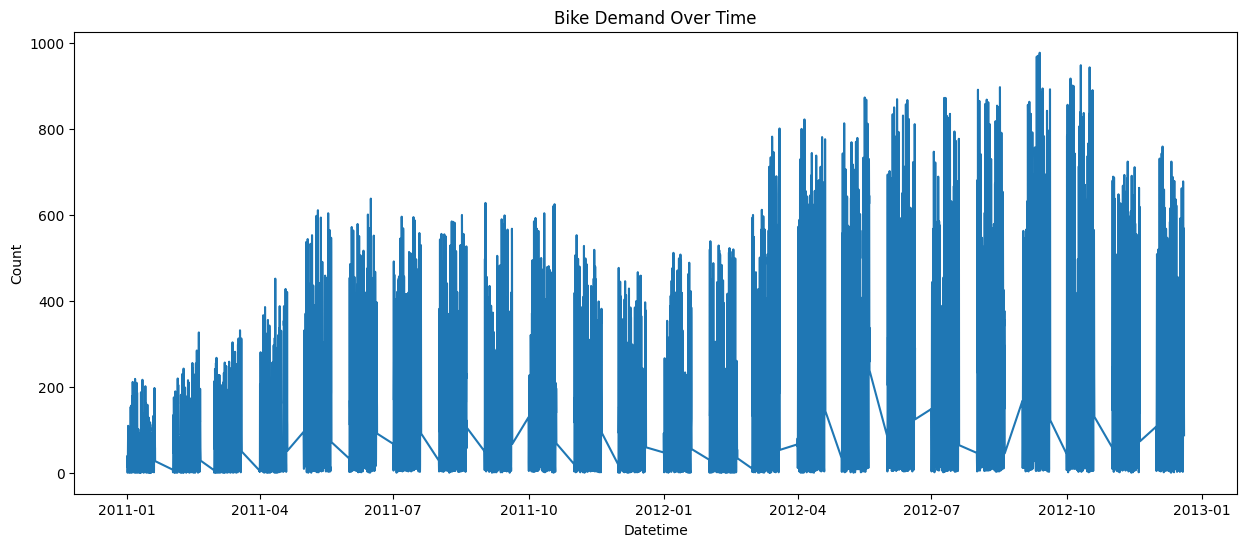

In [ ]:
# 모델마다 엄청난 차이가 보입니다! 왜 그럴까요?
# 시각화를 해보면서 그 이유를 찾아봅시다.
# 데이터의 형태를 보고 회귀 모델보다 이진트리 모델들이 왜 예측을 잘하는 지 예측해보세요.

plt.figure(figsize=(15, 6))
sns.lineplot(x='datetime', y='count', data=train)
plt.title('Bike Demand Over Time')
plt.xlabel('Datetime')
plt.ylabel('Count')
plt.show()

- 데이터가 직선적 관계가 아니라 시간에 따른 주기성을 보임
- 변동 폭이 구간마다 달라 분산이 일정하지 않음
​- 그래서 전역적으로 한 번에 직선을 맞추는 선형회귀는 구조적으로 불리함
- 입력 공간을 임계값으로 쪼개 구간별 규칙을 학습하는 결정트리/앙상블이 비선형·문턱값 패턴을 더 적합함